In [1]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using CairoMakie
using LaTeXStrings

using JLD2
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/model/rhombohedral/plotters.jl")

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


aux_plot_map (generic function with 1 method)

In [ ]:
pdpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8a.jld"
pdpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8apresets.jld"
drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8b.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8bpresets.jld"
lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8c.jld"
lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig8cpresets.jld"
spinpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig9.jld"
spinpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Publication_datafiles/Fig9presets.jld"


In [3]:
# _, _, _, _, Ezs, νlist, matt = aux_plot_obs(spinpath, spinpresetpath, LMC.plot_lmcspin, flavor_filling = 1)

In [4]:

function lat_figure5(pdpath, pdpresetpath, lmcpath, lmcpresetpath, spinpath, spinpresetpath, Ezval; 
    fontsizetheme = 15)
    with_theme(merge(theme_latexfonts(), Theme(fontsize = fontsizetheme))) do #
        Figure5(pdpath, pdpresetpath, lmcpath, lmcpresetpath, spinpath, spinpresetpath, Ezval, fontsize = fontsizetheme)   
    end
end

using Interpolations, Statistics


#choose solution at boundary region
function interpolate_despike(x,y, threshold)
    good = detect_outliers(y, threshold)
    xg = x[good]
    yg = y[good]
    itp = linear_interpolation(xg, yg, extrapolation_bc = Line())
    return itp.(x)
end

function detect_outliers(data::AbstractVector{<:Real}, threshold::Real)
    n = length(data)
    good = trues(n)
    for i in 2:n-1
        avg_neighbors = (data[i-1] + data[i+1]) / 2
        if abs(data[i] - avg_neighbors) > threshold
            good[i] = false
        end
    end
    return good
end

function despike_forward!(d, threshold)
    data = zeros(length(d))
    n = length(data)
    data[1] = d[1]
    for i in 2:n-1
        left  = data[i-1]      # already filtered
        mid   = d[i]
        right = d[i+1]      # original (not yet filtered)

        avg_neighbors = (left + right) / 2
        deviation = abs(mid - avg_neighbors)

        if deviation > threshold && abs(right)-abs(mid) > threshold && abs(left)-abs(mid) > threshold || deviation > 10threshold
        data[i] = avg_neighbors
        else 
            data[i] = d[i]
        end
    end

    return data
end

function Figure5(pdpath, pdpresetpath, lmcpath, lmcpresetpath, spinpath, spinpresetpath, Ezval = 4.2; 
    fontsize = 8)
    fig = Figure(size = (600, 600))
    ga = fig[1:2,1:2] = GridLayout()
    ax1 = Axis(ga[1,1], xlabel = L"$\nu\text{ [}10^{12}\text{ cm}^{-2}\text{]}$", ylabel = L"$E_z \text{ [meV]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    ax2 = Axis(ga[1,2], xlabel = L"$\nu\text{ [}10^{12}\text{ cm}^{-2}\text{]}$", ylabel = L"$E_z \text{ [meV]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    # ax3 = Axis(ga[2,1], xlabel = L"$\nu\text{ [}10^{12}\text{ cm}^{-2}\text{]}$", ylabel = L"$E_z \text{ [meV]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    # ax4 = Axis(ga[2,2], xlabel = L"$\nu\text{ [}10^{12}\text{ cm}^{-2}\text{]}$", ylabel = L"$E_z \text{ [meV]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    ax5 = Axis(fig[2,1:2],  xlabel = L"$\nu\text{ [}10^{12}\text{ cm}^{-2}\text{]}$", ylabel =  L"$|\sigma_{xxx}|\text{ }[1/T e^2/h]$",  xlabelsize = fontsize +2, ylabelsize = fontsize +2, ylabelpadding = -8)
    ax5.yticks = ([-0.1,0,0.1], ["-0.1", "0", "0.1"])

    hideydecorations!(ax2, grid = false)
    hm = plot_lmc(ax1, lmcpath, lmcpresetpath, colorrange = [-0.05, 0.05], 
        absolute = false, flavor_filling = 1)
    hm = plot_lmc(ax2, lmcpath, lmcpresetpath, colorrange = [-0.05, 0.05],
         absolute = false, flavor_filling = 2)
    cb = Colorbar(ga[1,3], hm, label = L"$|\sigma^O_{xxx}|\text{ } [1/T e^2/h]$", 
        labelsize = fontsize +1, vertical = true, labelpadding = -15,
        ticks = ([-0.05,0,0.05], ["-0.05","0","0.05"]), ticklabelpad = 2, 
        ticklabelsize = fontsize, ticksize = 4)
    # hm = plot_lmcspin(ax3, spinpath, spinpresetpath, colorrange = [-0.05, 0.05],
    #      absolute = false, flavor_filling = 1 )
    # hm = plot_lmcspin(ax4, spinpath, spinpresetpath, colorrange = [-0.05, 0.05], 
    #     absolute = false, flavor_filling = 2)
    # cb = Colorbar(ga[2,3], hm, label = L"$|\sigma^S_{xxx}|\text{ } [1/T e^2/h]$", labelsize = fontsize +1, 
    #     vertical = true, labelpadding = -15,
    # ticks = ([-0.05,0,0.05], ["-0.05","0","0.05"]), ticklabelpad = 2, ticklabelsize = fontsize, 
    #     ticksize = 4)
    ymin = 0
    ymax = 10

    # [xlims!(ax, xmin, xmax) for ax in [ax1,ax2,ax3,ax4]]
    [ylims!(ax, ymin, ymax) for ax in [ax1,ax2]]



    #_________________________________________

    _, _, _, _, Ezs, νlist, matt = aux_plot_obs(lmcpath, lmcpresetpath, LMC.plot_lmc, flavor_filling = 1)
    _, _, _, _, Ezss, νlists, matts = aux_plot_obs(spinpath, spinpresetpath, LMC.plot_lmcspin, flavor_filling = 1)

    νlist .*= prefactor_filling()/1e12 
    
    ν_noise = -0.21
    ν_noise2 = -0.15
    ν_noise *= prefactor_filling()/1e12 
    ν_noise2 *= prefactor_filling()/1e12 

    idxEz = argmin(abs.(Ezs .- Ezval))
    idxnu = argmin(abs.(νlist .- ν_noise))
    idxnu2 = argmin(abs.(νlist .- ν_noise2))
    lmcorbital_line =  matt'[:, idxEz]
    y_interp = interpolate_despike(νlist, lmcorbital_line, 0.005)

    spin_line = matts'[:, idxEz]
    y_interp_s = vcat(interpolate_despike(νlist[1:idxnu2], spin_line[1:idxnu2], 0.007), spin_line[idxnu2+1:end])
    # despike_forward!(y_interp, 1)

    lines!(ax5, νlist, -y_interp, color = :lightgray, linestyle = :solid)
    lines!(ax5, νlist, y_interp, color = :lightgray, linestyle = :solid)

    lines!(ax5, νlist[1:idxnu2], -y_interp[1:idxnu2] - abs.(y_interp_s[1:idxnu2]),  color = :blue, linewidth = 1.5, alpha = 1)
    lines!(ax5, νlist[idxnu2:end], -y_interp[idxnu2:end] - abs.(y_interp_s[idxnu2:end]),   color = :blue, linewidth = 1.5, alpha =1, label =L"$K\uparrow | K' \uparrow | K \downarrow |  K' \downarrow ")
    lines!(ax5, νlist[idxnu2:end], -y_interp[idxnu2:end] + abs.(y_interp_s[idxnu2:end]),  color = :red, linewidth = 1.5, alpha = 1,  label =L"$K\uparrow | K' \uparrow | K' \downarrow |  K \downarrow ")

    lines!(ax5, νlist[1:idxnu2], -y_interp[1:idxnu2] + abs.(y_interp_s[1:idxnu2]),  color = :red, linewidth = 1.5, alpha = 1)

    lines!(ax5, νlist[1:idxnu2], -y_interp[1:idxnu2] - abs.(y_interp_s[1:idxnu2]), color = :blue, linewidth = 1.5, alpha = 1)
    lines!(ax5, νlist[idxnu2:end], y_interp[idxnu2:end] + abs.(y_interp_s[idxnu2:end]),linestyle = :dash, color = :red, linewidth = 1.5, alpha = 1, label =L"$K\uparrow | K' \uparrow | K \downarrow |  K \downarrow ")

    lines!(ax5, νlist[1:idxnu2], -y_interp[1:idxnu2] + abs.(y_interp_s[1:idxnu2]), color = :red, linewidth = 1.5, alpha = 1)
    lines!(ax5, νlist[idxnu2:end], y_interp[idxnu2:end] - abs.(y_interp_s[idxnu2:end]), color = :blue, linestyle = :dash, linewidth = 1.5, alpha = 1, label =L"$K\downarrow | K' \downarrow | K \uparrow |  K \uparrow ")



    xlims!(ax5, -0.69, -0.0)
    ylims!(ax5, -0.12, 0.12)

    vspan!(ax5, -0.57,-0.28, color = (:blue, 0.1))
    vspan!(ax5, -0.07,0.1, color = (:gray, 0.2))
    


    lines!(ax1, [-0.73,0], [Ezval, Ezval], linewidth = 1.5, color = :orange)
    lines!(ax2, [-0.73,0], [Ezval, Ezval], linewidth = 1.5, color = :orange)
    # lines!(ax3, [-0.73,0], [Ezval, Ezval], linewidth = 1.5, color = :orange)
    # lines!(ax4, [-0.73,0], [Ezval, Ezval], linewidth = 1.5, color = :orange)
    
    # lines!(ax5, νlist, fdataorbital)
    #_________________________________________
    Label(ga[1, 1, TopLeft()], "a)",
        fontsize = fontsize,
        padding = (0, 35, -0, 0),
        halign = :right)

    Label(ga[1, 2, TopLeft()], "b)",
    fontsize = fontsize,
    padding = (0, 5, -0, 0),
    halign = :right)

    Label(ga[2, 1:2, TopLeft()], "c)",
    fontsize = fontsize,
    padding = (0, 35, -0, 0),
    halign = :right)

    # Label(ga[2, 2, TopLeft()], "d)",
    # fontsize = fontsize,
    # padding = (0, 5, -0, 0),
    # halign = :right)

    # Label(fig[3, 1:2, TopLeft()], "e)",
    # fontsize = fontsize,
    # padding = (0, 35, -0, 0),
    # halign = :right)

    colgap!(ga, 10)
    rowgap!(ga, 10)
    rowgap!(fig.layout, 30) 
    fig
end

Figure5 (generic function with 2 methods)

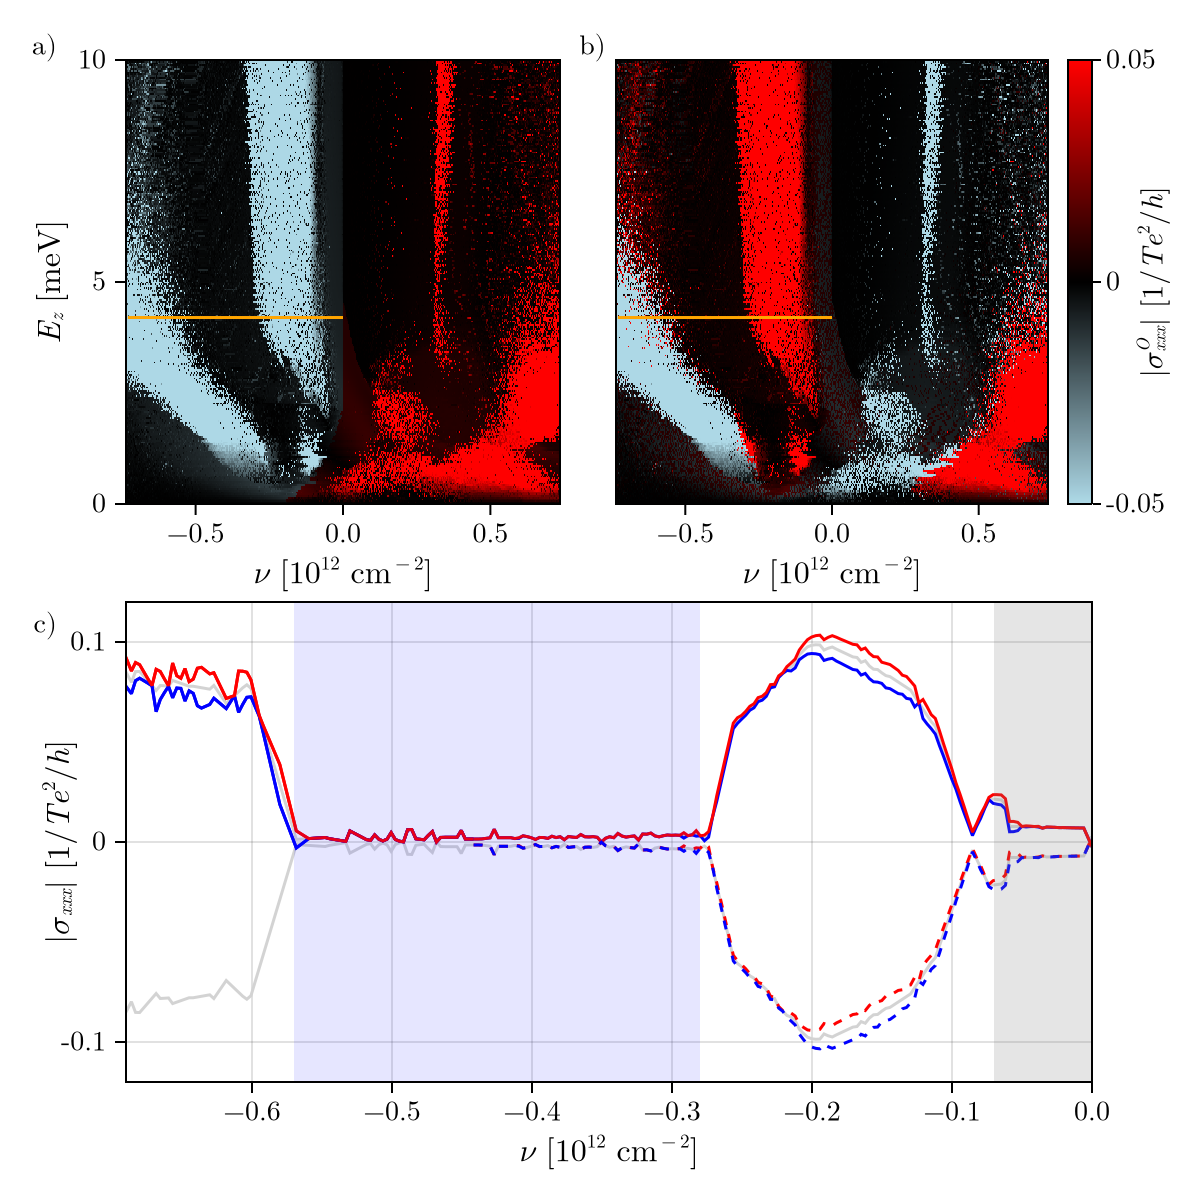

In [348]:
Ezval = 4.2
fig5 = lat_figure5(pdpath, pdpresetpath, lmcpath, lmcpresetpath, spinpath, spinpresetpath, Ezval; fontsizetheme = 14)

In [349]:
v = "v2"
save("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Figures/Figure5$(v).pdf", fig5)

CairoMakie.Screen{PDF}


In [3]:
# _, _, _, _, Ezs, νlist, matt = aux_plot_obs(lmcpath, lmcpresetpath, LMC.plot_lmc, flavor_filling = 1)
# _, _, _, _, Ezs, νlist, matts = aux_plot_obs(spinpath, spinpresetpath, LMC.plot_lmcspin, flavor_filling = 1)

("3321232", "3238850", "3237618", 100000, Any[-10.0, -9.959919839679358, -9.919839679358718, -9.879759519038076, -9.839679358717435, -9.799599198396793, -9.759519038076153, -9.719438877755511, -9.67935871743487, -9.639278557114228  …  9.639278557114228, 9.67935871743487, 9.719438877755511, 9.759519038076153, 9.799599198396793, 9.839679358717435, 9.879759519038076, 9.919839679358718, 9.959919839679358, 10.0], [-0.25, -0.249, -0.248, -0.247, -0.246, -0.245, -0.244, -0.243, -0.242, -0.241  …  0.241, 0.242, 0.243, 0.244, 0.245, 0.246, 0.247, 0.248, 0.249, 0.25], [1.0686418755109783e-9 4.78654235172841e-5 … -0.0149737550265887 0.0; -5.691647244137948e-6 -5.569134152942477e-5 … 0.014687673049875432 0.0; … ; 1.4897405226305463e-8 -7.3018175783133e-5 … 0.014687275924367516 0.0; -0.009584889583685065 -0.009582713216944923 … -0.0001375245595443865 0.0])